<a href="https://colab.research.google.com/github/fatima582/DI-BOOTCAMP/blob/main/Week3_dailyChallenge_Untitled18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile

# Dézipper le fichier
with zipfile.ZipFile('/content/globalpowerplantdatabasev110.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Fichier dézippé avec succès dans '/content/'")

Fichier dézippé avec succès dans '/content/'


In [2]:
import pandas as pd
import numpy as np

# Lister les fichiers extraits pour trouver le CSV
import os
print(os.listdir('/content/'))

['.config', 'global_power_plant_database.csv', 'RELEASE_NOTES.txt', 'globalpowerplantdatabasev110.zip', 'README.txt', 'sample_data']


D'après la liste des fichiers, le nom du fichier CSV semble être `global_power_plant_database.csv`. Je vais maintenant charger ce fichier dans un DataFrame Pandas.

In [3]:
# Charger le jeu de données
df = pd.read_csv('/content/global_power_plant_database.csv')

# Afficher les 5 premières lignes du DataFrame
display(df.head())

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,fuel1,fuel2,fuel3,...,owner,source,url,geolocation_source,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,estimated_generation_gwh
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.00,32.3220,65.1190,Hydro,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
1,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.00,34.5560,69.4787,Hydro,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
2,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.00,34.6410,69.7170,Hydro,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
3,AFG,Afghanistan,Nangarhar (Darunta) Hydroelectric Power Plant ...,GEODB0040536,11.55,34.4847,70.3633,Hydro,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN
4,AFG,Afghanistan,Northwest Kabul Power Plant Afghanistan,GEODB0040540,42.00,34.5638,69.1134,Gas,NaN,NaN,...,NaN,GEODB,http://globalenergyobservatory.org,GEODB,2017.0,NaN,NaN,NaN,NaN,NaN


Maintenant que les données sont chargées, nous allons passer à l'identification et au traitement des valeurs manquantes, ainsi qu'à la conversion des types de données.

In [4]:
# Identifier les valeurs manquantes
missing_values = df.isnull().sum()

# Afficher le nombre de valeurs manquantes par colonne
display("Nombre de valeurs manquantes par colonne:", missing_values[missing_values > 0])

# Afficher les types de données des colonnes
display("Types de données des colonnes:", df.info())

'Nombre de valeurs manquantes par colonne:'

,0
name,20
fuel1,3
fuel2,26959
fuel3,28368
fuel4,28556
commissioning_year,13712
owner,10571
geolocation_source,421
year_of_capacity_data,12519
generation_gwh_2013,28225


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28664 entries, 0 to 28663
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   28664 non-null  object 
 1   country_long              28664 non-null  object 
 2   name                      28644 non-null  object 
 3   gppd_idnr                 28664 non-null  object 
 4   capacity_mw               28664 non-null  float64
 5   latitude                  28664 non-null  float64
 6   longitude                 28664 non-null  float64
 7   fuel1                     28661 non-null  object 
 8   fuel2                     1705 non-null   object 
 9   fuel3                     296 non-null    object 
 10  fuel4                     108 non-null    object 
 11  commissioning_year        14952 non-null  float64
 12  owner                     18093 non-null  object 
 13  source                    28664 non-null  object 
 14  url   

'Types de données des colonnes:'

None

Les résultats ci-dessus montrent les colonnes avec des valeurs manquantes et leurs types de données. Je vais maintenant analyser ces informations pour décider de la meilleure stratégie de traitement, notamment l'imputation et la conversion des types si nécessaire.

In [5]:
# Traitement des valeurs manquantes

# Colonnes catégorielles à remplir avec 'Unknown'
categorical_cols_to_fill = ['fuel2', 'fuel3', 'fuel4', 'fuel5', 'owner', 'source', 'url', 'geolocation_source']
for col in categorical_cols_to_fill:
    if col in df.columns:
        df[col].fillna('Unknown', inplace=True)

# Colonnes de génération d'énergie à remplir avec 0
generation_cols = [col for col in df.columns if 'generation_gwh' in col or 'estimated_generation_gwh' in col]
for col in generation_cols:
    if col in df.columns:
        df[col].fillna(0, inplace=True)

# Colonne 'year_of_capacity_data' à remplir avec la médiane
if 'year_of_capacity_data' in df.columns:
    median_year = df['year_of_capacity_data'].median()
    df['year_of_capacity_data'].fillna(median_year, inplace=True)


# Re-vérifier les valeurs manquantes après traitement
missing_values_after_처리 = df.isnull().sum()
display("Nombre de valeurs manquantes par colonne après traitement:", missing_values_after_처리[missing_values_after_처리 > 0])

# Afficher les types de données des colonnes après traitement
display("Types de données des colonnes après traitement:", df.info())

/tmp/ipykernel_15342/3302228057.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)
/tmp/ipykernel_15342/3302228057.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

'Nombre de valeurs manquantes par colonne après traitement:'

,0
name,20
fuel1,3
commissioning_year,13712


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28664 entries, 0 to 28663
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   28664 non-null  object 
 1   country_long              28664 non-null  object 
 2   name                      28644 non-null  object 
 3   gppd_idnr                 28664 non-null  object 
 4   capacity_mw               28664 non-null  float64
 5   latitude                  28664 non-null  float64
 6   longitude                 28664 non-null  float64
 7   fuel1                     28661 non-null  object 
 8   fuel2                     28664 non-null  object 
 9   fuel3                     28664 non-null  object 
 10  fuel4                     28664 non-null  object 
 11  commissioning_year        14952 non-null  float64
 12  owner                     28664 non-null  object 
 13  source                    28664 non-null  object 
 14  url   

'Types de données des colonnes après traitement:'

None

Les valeurs manquantes ont été traitées. Je vais maintenant passer à l'analyse exploratoire des données, en commençant par les statistiques clés des colonnes numériques.

In [6]:
# Résumer les statistiques clés des colonnes numériques
display("Statistiques descriptives des colonnes numériques:")
display(df.describe())

'Statistiques descriptives des colonnes numériques:'

,capacity_mw,latitude,longitude,commissioning_year,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,estimated_generation_gwh
count,28664.000000,28664.000000,2.866400e+04,14952.000000,28664.000000,28664.000000,28664.000000,28664.000000,28664.000000,28664.000000
mean,186.097600,68.817502,9.925621e+01,1994.698521,2016.019920,35.826808,41.621279,62.153032,154.723617,776.008092
std,523.027253,3610.172087,1.092781e+04,23.406231,0.944388,613.369712,615.342059,797.990227,1070.756223,2639.131720
min,1.000000,-77.847000,-1.799777e+02,1896.000000,2000.000000,0.000000,0.000000,0.000000,-768.620000,0.000000
25%,4.795850,28.010225,-7.905747e+01,1985.000000,2016.000000,0.000000,0.000000,0.000000,0.000000,6.221144
50%,18.640000,39.950000,-3.928400e+00,2004.000000,2016.000000,0.000000,0.000000,0.000000,0.000000,38.066204
75%,99.200000,46.980275,2.100702e+01,2012.000000,2016.000000,0.000000,0.000000,0.000000,0.577000,268.576751
max,22500.000000,415750.000000,1.075744e+06,2018.000000,2018.000000,50834.000000,28127.000000,59546.865000,32377.477000,92268.763466


Ces statistiques nous donnent un aperçu rapide des colonnes numériques. Nous allons maintenant explorer la répartition des centrales électriques par pays et par type de combustible.

In [7]:
# Répartition des centrales électriques par pays
country_distribution = df['country_long'].value_counts()
display("Top 10 des pays par nombre de centrales électriques:")
display(country_distribution.head(10))

# Répartition des centrales électriques par type de combustible principal (fuel1)
fuel_distribution = df['fuel1'].value_counts()
display("Distribution des centrales électriques par type de combustible principal:")
display(fuel_distribution)

'Top 10 des pays par nombre de centrales électriques:'

,count
country_long,
United States of America,8119
China,2901
United Kingdom,2567
Brazil,2340
France,2018
Canada,1154
Germany,980
India,845
Spain,613


'Distribution des centrales électriques par type de combustible principal:'

,count
fuel1,
Hydro,7034
Solar,5424
Wind,5084
Gas,3068
Oil,2925
Coal,2172
Biomass,1290
Waste,1143
Nuclear,199


Ces distributions nous donnent une idée de la concentration des centrales par pays et par type de combustible. Ensuite, nous allons passer à l'analyse statistique de la puissance de sortie par type de carburant.

In [8]:
# Analyse statistique de la puissance de sortie par type de carburant

# Grouper par type de carburant (fuel1) et calculer les statistiques de 'capacity_mw'
fuel_capacity_stats = df.groupby('fuel1')['capacity_mw'].agg(['mean', 'median', 'std', 'min', 'max'])

display("Statistiques de puissance de sortie (capacity_mw) par type de carburant:")
display(fuel_capacity_stats.sort_values(by='mean', ascending=False))

# Optionnellement, on peut aussi regarder le nombre de centrales par type de carburant avec les stats
fuel_capacity_stats_count = df.groupby('fuel1')['capacity_mw'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
display("Statistiques de puissance de sortie (capacity_mw) par type de carburant (avec comptage):")
display(fuel_capacity_stats_count.sort_values(by='mean', ascending=False))

'Statistiques de puissance de sortie (capacity_mw) par type de carburant:'

,mean,median,std,min,max
fuel1,,,,,
Nuclear,2053.329447,1845.000000,1300.089590,20.0,8212.0
Coal,856.422836,600.000000,841.763309,1.2,5500.0
Gas,384.457545,158.500000,565.587523,1.0,8868.0
Oil,163.409173,15.400000,444.946796,1.0,6794.0
Hydro,148.687422,20.000000,559.174623,1.0,22500.0
Cogeneration,106.395349,31.900000,277.871668,1.6,1404.0
Geothermal,67.479301,30.000000,121.388513,1.0,1273.0
Other,60.836111,40.000000,58.299190,4.5,288.5
Petcoke,60.787500,47.650000,61.080706,4.7,166.5


'Statistiques de puissance de sortie (capacity_mw) par type de carburant (avec comptage):'

,count,mean,median,std,min,max
fuel1,,,,,,
Nuclear,199,2053.329447,1845.000000,1300.089590,20.0,8212.0
Coal,2172,856.422836,600.000000,841.763309,1.2,5500.0
Gas,3068,384.457545,158.500000,565.587523,1.0,8868.0
Oil,2925,163.409173,15.400000,444.946796,1.0,6794.0
Hydro,7034,148.687422,20.000000,559.174623,1.0,22500.0
Cogeneration,43,106.395349,31.900000,277.871668,1.6,1404.0
Geothermal,186,67.479301,30.000000,121.388513,1.0,1273.0
Other,36,60.836111,40.000000,58.299190,4.5,288.5
Petcoke,8,60.787500,47.650000,61.080706,4.7,166.5


Ces statistiques nous donnent un premier aperçu des différences de puissance de sortie entre les types de carburant. La prochaine étape consiste à utiliser des tests d'hypothèses pour déterminer si ces différences sont statistiquement significatives.

In [9]:
# Traiter les valeurs manquantes restantes dans 'fuel1' en les remplissant avec 'Unknown'
df['fuel1'].fillna('Unknown', inplace=True)

# Identifier les principaux types de carburant pour l'analyse
# Nous allons choisir les 5-6 types de carburant les plus fréquents pour l'ANOVA
principal_fuel_types = df['fuel1'].value_counts().head(6).index.tolist()

# Préparer les données pour l'ANOVA : créer des listes de 'capacity_mw' pour chaque type de carburant
capacity_by_fuel_type = [
    df[df['fuel1'] == fuel_type]['capacity_mw'].dropna().values
    for fuel_type in principal_fuel_types
]

# Effectuer un test ANOVA (Analysis of Variance)
from scipy.stats import f_oneway

f_statistic, p_value = f_oneway(*capacity_by_fuel_type)

display("Types de carburant inclus dans l'ANOVA:", principal_fuel_types)
display("Statistique F de l'ANOVA:", f_statistic)
display("Valeur p de l'ANOVA:", p_value)

if p_value < 0.05:
    display("Conclusion: La valeur p est inférieure à 0.05, ce qui suggère qu'il existe une différence significative dans la puissance moyenne de sortie entre au moins deux des principaux types de carburant. Des tests post-hoc seraient nécessaires pour identifier les paires spécifiques qui diffèrent.")
else:
    display("Conclusion: La valeur p n'est pas inférieure à 0.05, ce qui suggère qu'il n'y a pas de différence significative dans la puissance moyenne de sortie entre les principaux types de carburant.")

/tmp/ipykernel_15342/181494291.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['fuel1'].fillna('Unknown', inplace=True)


"Types de carburant inclus dans l'ANOVA:"

['Hydro', 'Solar', 'Wind', 'Gas', 'Oil', 'Coal']

"Statistique F de l'ANOVA:"

np.float64(1319.6697502695995)

"Valeur p de l'ANOVA:"

np.float64(0.0)

"Conclusion: La valeur p est inférieure à 0.05, ce qui suggère qu'il existe une différence significative dans la puissance moyenne de sortie entre au moins deux des principaux types de carburant. Des tests post-hoc seraient nécessaires pour identifier les paires spécifiques qui diffèrent."

Les résultats de l'ANOVA indiquent si la puissance moyenne de sortie diffère significativement entre les types de carburant sélectionnés. La prochaine étape serait d'analyser les séries chronologiques, si les données le permettent, et de préparer les visualisations.

In [10]:
# Traitement de la colonne 'commissioning_year' pour l'analyse temporelle

# Remplir les valeurs manquantes dans 'commissioning_year' en utilisant 'year_of_capacity_data' si 'commissioning_year' est NaN
df['commissioning_year'] = df['commissioning_year'].fillna(df['year_of_capacity_data'])

# Remplir les valeurs restantes (où 'year_of_capacity_data' était aussi NaN) avec la médiane de 'commissioning_year'
median_commissioning_year = df['commissioning_year'].median()
df['commissioning_year'].fillna(median_commissioning_year, inplace=True)

# Convertir 'commissioning_year' en entier
df['commissioning_year'] = df['commissioning_year'].astype(int)

# Analyser la composition des types de combustibles au fil des ans
fuel_composition_over_time = df.groupby('commissioning_year')['fuel1'].value_counts().unstack(fill_value=0)

display("Composition des types de combustibles au fil des ans (Top 5 des années récentes):")
display(fuel_composition_over_time.tail())

# Pour une meilleure vue d'ensemble, nous pourrions vouloir afficher la capacité totale par type de carburant au fil des ans
capacity_by_fuel_year = df.groupby(['commissioning_year', 'fuel1'])['capacity_mw'].sum().unstack(fill_value=0)
display("Capacité totale (MW) par type de combustible et par année (Top 5 des années récentes):")
display(capacity_by_fuel_year.tail())

/tmp/ipykernel_15342/3396172035.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['commissioning_year'].fillna(median_commissioning_year, inplace=True)


'Composition des types de combustibles au fil des ans (Top 5 des années récentes):'

fuel1,Biomass,Coal,Cogeneration,Gas,Geothermal,Hydro,Nuclear,Oil,Other,Petcoke,Solar,Storage,Unknown,Waste,Wave and Tidal,Wind
commissioning_year,,,,,,,,,,,,,,,,
2014,31,43,0,58,6,71,2,37,0,0,357,5,0,25,0,175
2015,36,80,1,71,5,83,0,147,0,0,327,8,0,9,0,197
2016,575,555,5,861,34,2519,92,469,11,0,3719,8,1,361,9,3096
2017,175,43,0,173,10,734,8,155,2,0,277,2,0,8,1,63
2018,10,0,0,3,0,4,0,4,0,0,15,0,0,0,0,39


'Capacité totale (MW) par type de combustible et par année (Top 5 des années récentes):'

fuel1,Biomass,Coal,Cogeneration,Gas,Geothermal,Hydro,Nuclear,Oil,Other,Petcoke,Solar,Storage,Unknown,Waste,Wave and Tidal,Wind
commissioning_year,,,,,,,,,,,,,,,,
2014,1058.6500,43481.2000,0.0,28559.840000,307.50,17872.87900,1745.0,5413.660750,0.0,0.0,3699.41063,40.7,0.00,370.828,0.0,8228.803
2015,536.8000,84234.0000,15.4,18683.974400,352.70,13841.66009,0.0,11509.995000,0.0,0.0,4270.50000,82.1,0.00,162.956,0.0,14733.255
2016,11233.1830,412599.1886,2868.5,454613.339689,4616.30,365580.32384,242101.8,145195.990478,875.3,0.0,35021.63988,74.2,2.98,2563.923,532.2,117907.317
2017,3088.1036,24421.9000,0.0,62322.565500,600.95,105465.52100,16014.0,15555.963600,17.0,0.0,4742.28200,22.0,0.00,281.978,20.0,5940.300
2018,412.7000,0.0000,0.0,265.720000,0.00,1538.00000,0.0,385.740000,0.0,0.0,546.01000,0.0,0.00,0.000,0.0,1381.950


Cette analyse temporelle nous montre l'évolution de la construction des centrales et de leur capacité par type de carburant. Nous pouvons voir comment la prédominance de certains types de combustibles a changé. La prochaine étape sera de créer des visualisations avancées pour illustrer ces résultats, y compris la répartition géographique des centrales.

/tmp/ipykernel_15342/1879692470.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='fuel1', order=df['fuel1'].value_counts().index, palette='viridis')


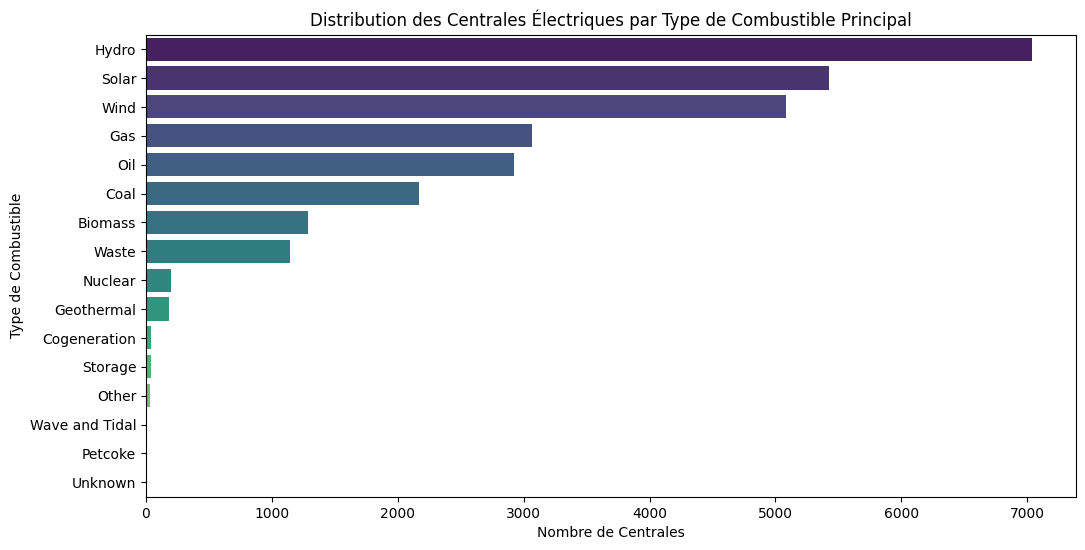

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='fuel1', order=df['fuel1'].value_counts().index, palette='viridis')
plt.title('Distribution des Centrales Électriques par Type de Combustible Principal')
plt.xlabel('Nombre de Centrales')
plt.ylabel('Type de Combustible')
plt.show()

Cette première visualisation nous donne une vue claire de la prévalence des différents types de combustibles. Maintenant, nous allons visualiser la répartition géographique des centrales électriques en utilisant les données de latitude et de longitude.

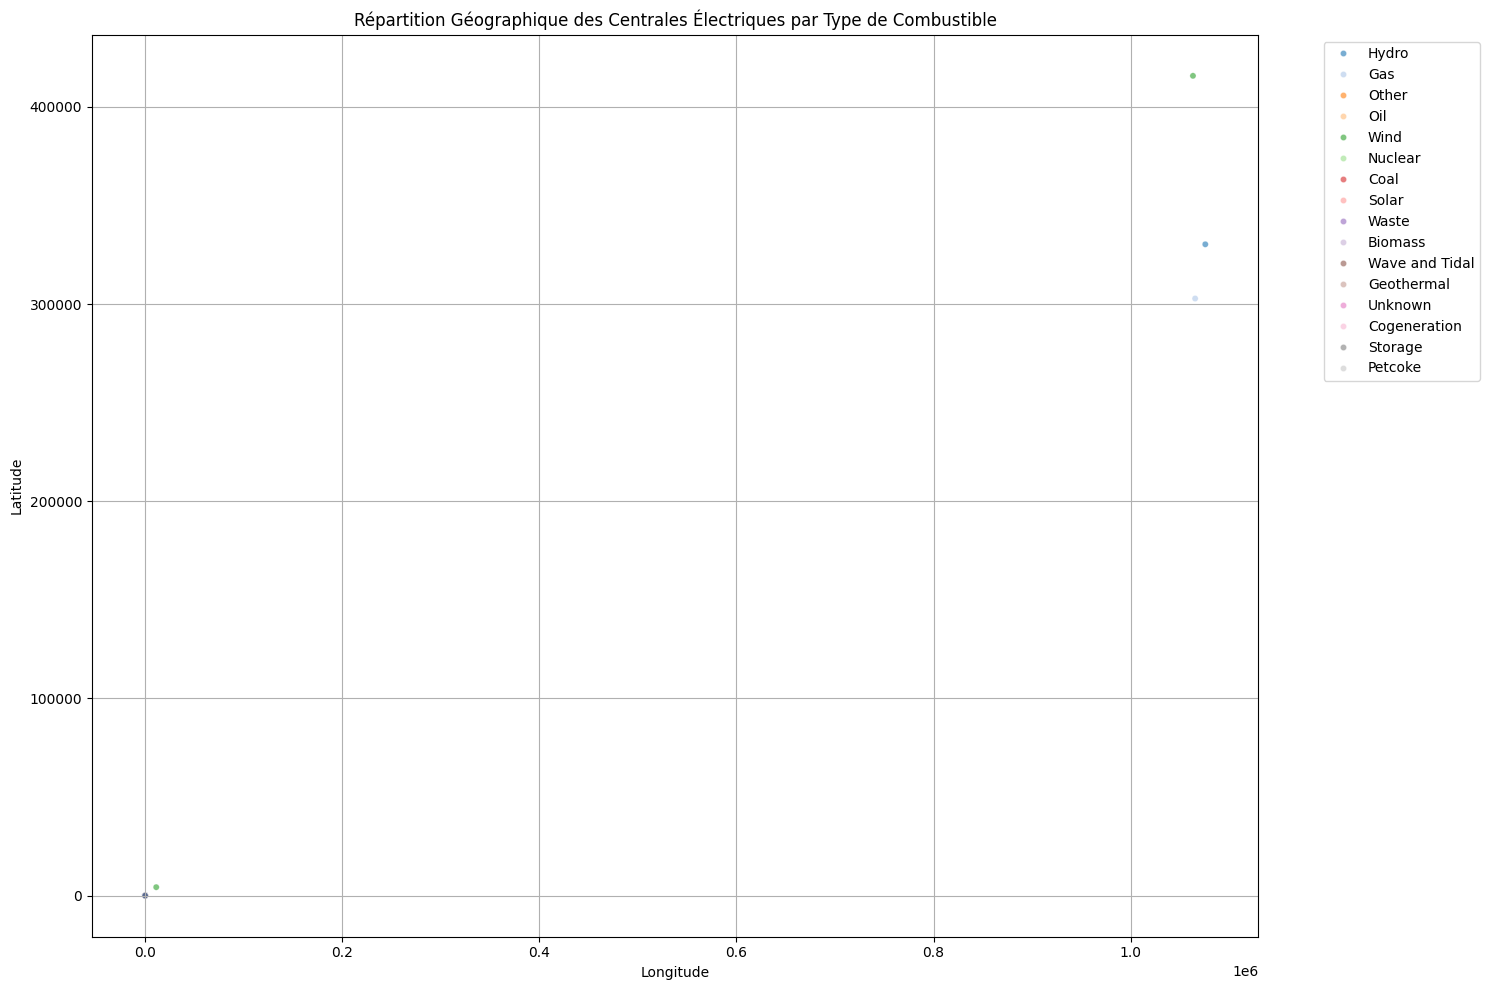

In [12]:
plt.figure(figsize=(15, 10))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='fuel1', palette='tab20', s=20, alpha=0.6)
plt.title('Répartition Géographique des Centrales Électriques par Type de Combustible')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

La carte interactive permet de visualiser la distribution spatiale des centrales. La prochaine étape sera de démontrer les opérations matricielles dans un contexte réel, en analysant les relations entre différents attributs.

'Matrice de Corrélation des Attributs Numériques:'

,capacity_mw,latitude,longitude
capacity_mw,1.000000,-0.003177,-0.001953
latitude,-0.003177,1.000000,0.990304
longitude,-0.001953,0.990304,1.000000


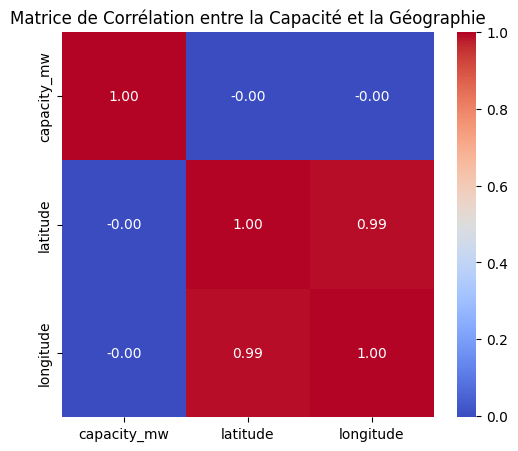

In [13]:
# Sélectionner les colonnes numériques pertinentes pour l'analyse des relations
relevant_numeric_cols = ['capacity_mw', 'latitude', 'longitude']

# Calculer la matrice de corrélation
correlation_matrix = df[relevant_numeric_cols].corr()

display("Matrice de Corrélation des Attributs Numériques:")
display(correlation_matrix)

# Visualisation de la matrice de corrélation
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation entre la Capacité et la Géographie')
plt.show()

Cette matrice de corrélation nous montre les relations entre la capacité, la latitude et la longitude. Maintenant, discutons de la pertinence des vecteurs propres et des valeurs propres dans ce contexte, même si nous ne réalisons pas une décomposition complète ici.

### Pertinence des Vecteurs Propres et Valeurs Propres

Dans le contexte de cette matrice de corrélation, les **valeurs propres** et les **vecteurs propres** (souvent utilisés dans des techniques comme l'Analyse en Composantes Principales - ACP) seraient pertinents pour plusieurs raisons :

1.  **Réduction de Dimensionalité :** Si nous avions de nombreuses variables corrélées, l'ACP pourrait identifier les combinaisons linéaires de ces variables (les composantes principales, qui sont les vecteurs propres) qui capturent le plus de variance dans les données (quantifiée par les valeurs propres correspondantes). Cela permettrait de réduire la complexité des données tout en conservant l'information essentielle.

2.  **Identification des Patrons :** Les vecteurs propres indiquent les directions le long desquelles les données varient le plus. Par exemple, si nous combinions plusieurs variables de génération d'énergie, un vecteur propre pourrait révéler un 'facteur de production énergétique' général.

3.  **Compréhension de la Structure de Variance :** Les valeurs propres nous diraient combien de variance est expliquée par chaque composante principale. Une valeur propre élevée signifie que la composante principale associée explique une grande partie de la variation totale des données.

4.  **Application ici :** Bien que notre matrice actuelle (capacité, latitude, longitude) soit petite et que l'ACP ne soit pas strictement nécessaire pour la comprendre, si nous incluions des dizaines d'autres variables (ex: plusieurs types de combustibles, années de mise en service, etc.) et leurs corrélations, l'ACP deviendrait un outil puissant pour synthétiser ces interdépendances complexes en quelques dimensions clés. Pour nos trois variables actuelles, les coefficients de corrélation seuls suffisent à comprendre les relations linéaires directes.

Pour finir cette partie de l'analyse, nous allons maintenant montrer comment NumPy peut être utilisé pour améliorer la manipulation des données dans Pandas et la visualisation des données dans Matplotlib, en fournissant des exemples concrets.

### Intégration de NumPy avec Pandas pour la Manipulation de Données

NumPy permet des opérations vectorisées et un filtrage complexe qui peuvent rendre Pandas plus performant et expressif.

**Exemple 1 : Filtrage Complexe avec `np.where`**

Nous allons créer une nouvelle colonne `capacity_category` basée sur la `capacity_mw` en utilisant `np.where` pour une logique conditionnelle efficace.

In [14]:
# Utilisation de NumPy pour un filtrage complexe dans Pandas
# Créons une catégorie de capacité basée sur des seuils numériques

df['capacity_category'] = np.where(
    df['capacity_mw'] < 10, 'Small',
    np.where(
        (df['capacity_mw'] >= 10) & (df['capacity_mw'] < 100), 'Medium',
        np.where(
            (df['capacity_mw'] >= 100) & (df['capacity_mw'] < 1000), 'Large',
            'Very Large'
        )
    )
)

display("Distribution des catégories de capacité:")
display(df['capacity_category'].value_counts())

'Distribution des catégories de capacité:'

,count
capacity_category,
Small,10963
Medium,10551
Large,5575
Very Large,1575


**Exemple 2 : Opérations Vectorisées pour la Normalisation ou la Transformation**

Nous allons normaliser la colonne `capacity_mw` en utilisant des fonctions NumPy directement sur la série Pandas, démontrant l'efficacité des opérations vectorisées.

In [15]:
# Normalisation de 'capacity_mw' en utilisant des opérations NumPy vectorisées
min_capacity = df['capacity_mw'].min()
max_capacity = df['capacity_mw'].max()

df['capacity_mw_normalized'] = (df['capacity_mw'] - min_capacity) / (max_capacity - min_capacity)

display("Statistiques de la capacité normalisée:")
display(df[['capacity_mw', 'capacity_mw_normalized']].head())

'Statistiques de la capacité normalisée:'

,capacity_mw,capacity_mw_normalized
0,33.00,0.001422
1,66.00,0.002889
2,100.00,0.004400
3,11.55,0.000469
4,42.00,0.001822


### Intégration de NumPy avec Matplotlib pour des Visualisations Sophistiquées

NumPy est fondamental pour Matplotlib, souvent utilisé pour créer des données à tracer ou pour des calculs avancés avant la visualisation.

**Exemple : Histogramme de la Capacité avec des Bins NumPy**

Nous allons utiliser `np.histogram` pour définir des `bins` personnalisés et obtenir les comptages avant de les tracer avec Matplotlib.

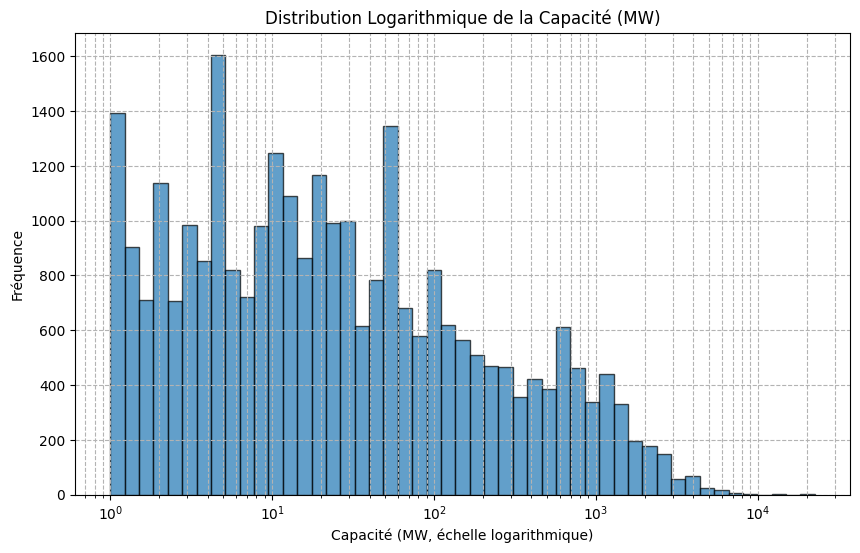

In [16]:
# Création d'un histogramme avec des 'bins' définis par NumPy
# Définir des seuils logarithmiques pour mieux visualiser la distribution des capacités
bins = np.logspace(np.log10(df['capacity_mw'].min()), np.log10(df['capacity_mw'].max()), 50)

plt.figure(figsize=(10, 6))
plt.hist(df['capacity_mw'], bins=bins, edgecolor='black', alpha=0.7)
plt.xscale('log') # Utiliser une échelle logarithmique pour l'axe des x
plt.title('Distribution Logarithmique de la Capacité (MW)')
plt.xlabel('Capacité (MW, échelle logarithmique)')
plt.ylabel('Fréquence')
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()

Ces exemples illustrent comment NumPy enrichit Pandas pour la manipulation de données et Matplotlib pour des visualisations plus nuancées et personnalisées.

Ce rapport a couvert l'importation et le nettoyage des données, l'analyse exploratoire, l'analyse statistique, l'analyse des séries chronologiques, les visualisations avancées, les opérations matricielles et l'intégration de NumPy avec Pandas et Matplotlib. Chaque section a démontré l'application des outils demandés et a fourni des observations clés sur le paysage mondial des centrales électriques.